# Creating and Discretizing Pipe in 1D 

In [16]:
import gmsh
import jax.numpy as jnp
import numpy as np

# Create pipe mesh in Gmsh
gmsh.initialize()
gmsh.model.add("pipe")

# Define pipe geometry: 1m long, 0.1m radius
L, R = 1.0, 0.1
tol = 1e-3  # tolerance for floating point comparisons

gmsh.model.occ.addCylinder(0, 0, 0,  # start point
                            L, 0, 0,  # direction and length
                            R)        # radius


gmsh.model.occ.synchronize()
# Get all 2D entities (surfaces)
surfaces = gmsh.model.getEntities(dim=2)
print("All surfaces:")

wall_tags    = []
inlet_tags   = []
outlet_tags  = []

for dim, tag in surfaces:
    # Get the bounding box of each surface, to determine which is which
    xmin, ymin, zmin, xmax, ymax, zmax = gmsh.model.getBoundingBox(dim, tag)
    
    # printing surfaces coordinates out to visualize the bounding boxes/their corredinates to confirm
    print(f"  Surface {tag}: "
          f"x=[{xmin:.3f},{xmax:.3f}] "
          f"y=[{ymin:.3f},{ymax:.3f}] "
          f"z=[{zmin:.3f},{zmax:.3f}]")
    
    # using bounding box more flexible approach to classify surfaces than relying on tags
    x_extent = xmax - xmin
    y_extent = ymax - ymin
    z_extent = zmax - zmin

    # Inlet cap: flat face at x=0
    # A flat circular cap at x=0 will have xmin≈xmax≈0
    if abs(xmin) < tol and abs(xmax) < tol:
        inlet_tags.append(tag)

    # Outlet cap: flat face at x=L
    # Same logic but at x=L
    elif abs(xmin - L) < tol and abs(xmax - L) < tol:
        outlet_tags.append(tag)

    # Wall: the cylindrical surface spans the full length
    # It extends from x=0 to x=L and has radial extent in y and z
    else:
        wall_tags.append(tag)

print(f"Identified wall surfaces   : {wall_tags}")
print(f"Identified inlet surfaces  : {inlet_tags}")
print(f"Identified outlet surfaces : {outlet_tags}")

'''
# assigning surfaces based on visual inspection of coordinates printed out
# Volume is unambiguous - there's only one
gmsh.model.addPhysicalGroup(3, [1], tag=4)
gmsh.model.setPhysicalName(3, 4, "fluid")

gmsh.model.addPhysicalGroup(2, [1], tag=1)
gmsh.model.setPhysicalName(2, 1, "wall")

gmsh.model.addPhysicalGroup(2, [2], tag=2)
gmsh.model.setPhysicalName(2, 2, "outlet")

gmsh.mode.setPhysicalName(2, 3, "inlet")

# Tag the volume too -- JAX-FEM needs this
gmsh.model.addPhysicalGroup(3, [1], tag=4)
gmsh.model.setPhysicalName(3, 4, "fluid")
'''


# Now assign physical groups with tags, not hard coded method 
gmsh.model.addPhysicalGroup(2, wall_tags,   tag=1)
gmsh.model.setPhysicalName(2, 1, "wall")
gmsh.model.addPhysicalGroup(2, inlet_tags,  tag=2)
gmsh.model.setPhysicalName(2, 2, "inlet")
gmsh.model.addPhysicalGroup(2, outlet_tags, tag=3)
gmsh.model.setPhysicalName(2, 3, "outlet")

# Get all surfaces that bound the fluid volume
# getBoundary returns (dim, tag) pairs — the surfaces forming the volume's skin
volume_boundary = gmsh.model.getBoundary([(3, 1)], oriented=False)
volume_boundary_tags = [tag for dim, tag in volume_boundary]

print(f"Surfaces bounding the fluid volume: {volume_boundary_tags}")
print(f"Wall tags   : {wall_tags}")
print(f"Inlet tags  : {inlet_tags}")
print(f"Outlet tags : {outlet_tags}")

# Sanity check — every boundary surface should be accounted for
all_surface_tags = set(wall_tags + inlet_tags + outlet_tags)
boundary_set = set(volume_boundary_tags)

unaccounted = boundary_set - all_surface_tags
if unaccounted:
    print(f"WARNING: these surfaces are on the volume boundary but "
          f"not assigned to any group: {unaccounted}")
else:
    print("OK: all volume boundary surfaces are accounted for")

# Assign the volume — using only the 3D entity, no surfaces
gmsh.model.addPhysicalGroup(3, [1], tag=4)
gmsh.model.setPhysicalName(3, 4, "fluid")

gmsh.model.mesh.generate(3)

# Set mesh size
gmsh.option.setNumber("Mesh.CharacteristicLengthMax", 0.05)
gmsh.model.mesh.generate(3)
# For ParaView visualization, temporarily remove the volume 
# physical group so only surfaces export to VTK
gmsh.model.removePhysicalGroups([(3, 4)])  # remove fluid volume group
gmsh.write("pipe.vtk")                      # now only surfaces write out

# Re-add it for the .msh (already written, so this is just housekeeping)
gmsh.model.addPhysicalGroup(3, [1], tag=4)
gmsh.model.setPhysicalName(3, 4, "fluid")


# After meshing...
elementTypes, elementTags, _ = gmsh.model.mesh.getElements(dim=3, tag=-1)
tetTags = elementTags[0]

qualities = gmsh.model.mesh.getElementQualities(tetTags, "gamma")

print(f"Min quality: {np.min(qualities):.4f}")
print(f"Mean quality: {np.mean(qualities):.4f}")
print(f"Elements below 0.2: {np.sum(np.array(qualities) < 0.2)}")

gmsh.finalize()
gmsh.model

All surfaces:
  Surface 1: x=[-0.000,1.000] y=[-0.100,0.100] z=[-0.100,0.100]
  Surface 2: x=[1.000,1.000] y=[-0.100,0.100] z=[-0.100,0.100]
  Surface 3: x=[-0.000,0.000] y=[-0.100,0.100] z=[-0.100,0.100]
Identified wall surfaces   : [1]
Identified inlet surfaces  : [3]
Identified outlet surfaces : [2]
Surfaces bounding the fluid volume: [1, 2, 3]
Wall tags   : [1]
Inlet tags  : [3]
Outlet tags : [2]
OK: all volume boundary surfaces are accounted for
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Circle)
Info    : [ 40%] Meshing curve 2 (Line)
Info    : [ 70%] Meshing curve 3 (Circle)
Info    : Done meshing 1D (Wall 0.000126416s, CPU 0.000158s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Cylinder, Frontal-Delaunay)
Info    : [ 40%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 3 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00399179s, CPU 0.003856s)
Info    : Meshing 3D...
Info    : 3D Meshing 1 volume with 1 conne

gmsh.model

# 1D two-phase solver in jax, for general pipe 1D

# Code with no floor implemented for fracture amounts

1D Two-Phase Mixture Flow Solver
  Grid:       N=500 cells, dx=0.0134 m
  Phase 1:    ρ=998.0 kg/m³
  Phase 2:    ρ=825.0 kg/m³
  phi1_0:     0.316
  phi2_0:     0.684
  ΔP drive:   612 Pa
  Drag coeff: 0.0001
  t_end:      200.0 s

  t=5.0000s  step=50000  dt=1.00e-04  vol_err=0.00e+00  max|u1|=0.3659  max|u2|=0.4407
phi1 min=0.314271 phi1 max=0.315603 phi2 min=0.684397 phi2 max=0.685729
  t=10.0000s  step=100000  dt=1.00e-04  vol_err=0.00e+00  max|u1|=0.4857  max|u2|=0.5811
phi1 min=0.313575 phi1 max=0.315607 phi2 min=0.684393 phi2 max=0.686425
  t=15.0000s  step=150000  dt=1.00e-04  vol_err=0.00e+00  max|u1|=0.5113  max|u2|=0.6069
phi1 min=0.312643 phi1 max=0.315600 phi2 min=0.684400 phi2 max=0.687357
  t=20.0000s  step=200000  dt=1.00e-04  vol_err=0.00e+00  max|u1|=0.5182  max|u2|=0.6101
phi1 min=0.311712 phi1 max=0.315600 phi2 min=0.684400 phi2 max=0.688288
  t=25.0000s  step=250000  dt=1.00e-04  vol_err=0.00e+00  max|u1|=0.5217  max|u2|=0.6097
phi1 min=0.310984 phi1 max=0.315600 

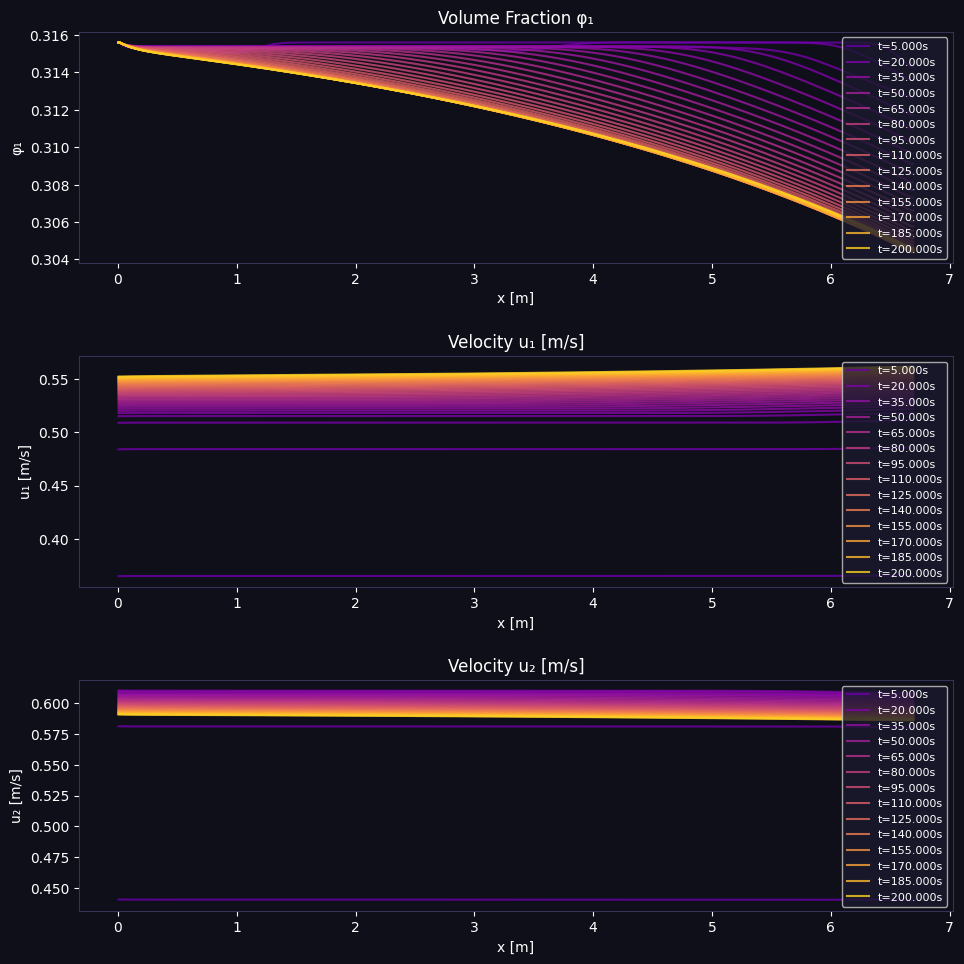

Plot saved to mixture_flow_result.png
U_m at inlet:   0.5786 m/s
U_m at midpipe: 0.5785 m/s
U_m at outlet:  0.5785 m/s
Variation:      0.0000 m/s
phi1 plateau:    0.3116  (input was 0.3156)
phi2 plateau:    0.6884
u1 (water):      0.5557 m/s
u2 (oil):        0.5889 m/s
U_m predicted:   0.5786 m/s
U_m target:      0.5000 m/s
Error:           15.71%


'\nvalidation_plot.py\n------------------\nGenerates two validation plots comparing your two-fluid model predictions\nagainst Ibarra et al. (2015) experimental data.\n\n    Plot 1 — WC vs Mixture Velocity (one subplot per Um)\n             Shows predicted Um against the experimental target line\n             for each water cut tested.\n\n    Plot 2 — Parity plot (Um measured vs Um predicted)\n             All conditions on one plot, colored by mixture velocity,\n             with 1:1 line and ±10% error bands.\n\nCSV FORMAT EXPECTED\n-------------------\nOne file per mixture velocity, e.g. ibarra_Um_0p50.csv\nColumns:\n    WC               — water cut (input volume fraction)\n    dpdz_measured    — pressure gradient Pa/m from Figure 10\n    Um_target        — target mixture velocity m/s (constant per file)\n    flow_regime      — flow regime string from Figure 6 (SW, SWD, DC, etc.)\n    phi1_predicted   — model steady-state water volume fraction\n    u1_predicted     — model steady-sta

In [ ]:
"""
1D Two-Phase Mixture Flow Solver in JAX
========================================

Solves the two-phase mixture theory equations for flow in a 1D pipe using
explicit time integration with a pressure projection method to enforce
volume conservation.

GOVERNING EQUATIONS (per phase α = 1, 2):

  Mass:
    ∂(φ_α ρ_α)/∂t + ∂(φ_α ρ_α u_α)/∂x = 0

  Momentum:
    ∂(φ_α ρ_α u_α)/∂t + ∂(φ_α ρ_α u_α² + φ_α p)/∂x
        = p ∂φ_α/∂x + M_α

  Volume constraint:
    φ₁ + φ₂ = 1   (enforced via pressure projection)

  Inter-phase drag (Stokes):
    M₁ =  C_d φ₁ φ₂ (u₂ - u₁)
    M₂ = -M₁

SOLUTION SEQUENCE PER TIME STEP:
  1. Advance mass equations    → new φ₁, φ₂
  2. Advance momentum eqs      → intermediate velocities u₁*, u₂*
  3. Pressure Poisson solve    → pressure correction dp
  4. Velocity projection       → volume-conserving u₁, u₂
  5. Algebraic cleanup         → enforce φ₂ = 1 - φ₁

NUMERICAL METHODS:
  - Spatial:  Lax-Friedrichs flux (upwind-biased, stable for convection)
  - Time:     Forward Euler (RK2 commented out at bottom for easy upgrade)
  - Pressure: Thomas algorithm (tridiagonal solve — exact in 1D, O(N))
  - BCs:      Fixed pressure inlet, zero-gradient outlet
"""

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import importlib
import bb_to_model_inputs as _bb_mod
importlib.reload(_bb_mod)
from bb_to_model_inputs import bb_to_model_inputs

# Force JAX to use 64-bit floats — critical for numerical stability in PDEs.
# By default JAX uses 32-bit, which accumulates floating point error quickly
# in time-marching solvers.
jax.config.update("jax_enable_x64", True)


# =============================================================================
# SECTION 1: GRID SETUP
# =============================================================================
# We use a finite volume method on a uniform 1D grid.
# Each "cell" is a control volume of width dx.
# Variables are stored at cell centers.
# Fluxes are computed at cell faces (between centers).
#
#   |--dx--|--dx--|--dx--|
#   |  0   |  1   |  2   |  ...  |  N-1  |   <- cell indices
#   ^      ^      ^                        <- face indices (N+1 faces total)
#   0      1      2                N
#
# Cell centers: x[i] = (i + 0.5) * dx
# Faces:        x_face[i] = i * dx

def make_grid(L, N):
    """
    Create a uniform 1D finite volume grid.
    
    L : float — pipe length [m]
    N : int   — number of cells
    
    Returns dx (cell width) and x (cell center coordinates).
    """
    dx = L / N
    x  = (jnp.arange(N) + 0.5) * dx   # cell centers, shape (N,)
    return dx, x


# =============================================================================
# SECTION 2: INITIAL CONDITIONS
# =============================================================================
# At t=0 we set the state of every cell in the pipe.
# Everything is at rest initially (u=0), with uniform volume fractions
# and a linear pressure gradient from inlet to outlet.

def initial_conditions(x, L, phi1_0, rho1, rho2, p_inlet, p_outlet):
    """
    Set initial conditions across all cells.

    x       : (N,) cell center coordinates
    L       : pipe length
    phi1_0  : initial volume fraction of phase 1 (uniform)
    rho1    : density of phase 1 [kg/m³]
    rho2    : density of phase 2 [kg/m³]
    p_inlet : inlet pressure [Pa]
    p_outlet: outlet pressure [Pa]

    Returns a dict of state arrays, each shape (N,).
    """
    N = len(x)

    phi1 = jnp.full(N, phi1_0)
    phi2 = 1.0 - phi1                          # volume constraint at t=0

    u1   = jnp.zeros(N)                        # both phases at rest
    u2   = jnp.zeros(N)

    # Linear pressure profile: high at inlet, low at outlet
    phi2_min = 1e-4
    #phi2_min = 7.5e-4
    phi1     = jnp.full(N, phi1_0)
    phi2     = jnp.maximum(1.0 - phi1, phi2_min)
    phi1     = 1.0 - phi2    # re-normalize so phi1 + phi2 = 1 exactly

    u1 = jnp.zeros(N)
    u2 = jnp.zeros(N)

    # This is the driving force for the flow
    p    = p_inlet + (p_outlet - p_inlet) * (x / L)

    return dict(phi1=phi1, phi2=phi2, u1=u1, u2=u2, p=p,
                rho1=jnp.full(N, rho1), rho2=jnp.full(N, rho2))


def initial_conditions_slug(x, L, rho1, rho2, p_inlet, p_outlet):
    N = len(x)
    
    # Step discontinuity at x = L/2
    # Left: 80% liquid (phase 1), Right: 20% liquid
    phi1 = jnp.where(x < L / 2, 0.8, 0.2)
    phi2 = 1.0 - phi1

    # Both phases initially at rest
    u1 = jnp.zeros(N)
    u2 = jnp.zeros(N)

    # Linear pressure gradient to drive flow left to right
    p = p_inlet + (p_outlet - p_inlet) * (x / L)

    return dict(phi1=phi1, phi2=phi2, u1=u1, u2=u2, p=p,
                rho1=jnp.full(N, rho1), rho2=jnp.full(N, rho2))



# =============================================================================
# SECTION 3: CFL TIME STEP
# =============================================================================
# The CFL (Courant-Friedrichs-Lewy) condition is a stability requirement for
# explicit time integration. It says: information cannot travel more than one
# cell per time step. If dt is too large, the numerical scheme sees a wave
# "jump over" a cell and the solution blows up.
#
# dt < CFL * dx / max_wavespeed
#
# We use CFL=0.4 (conservative — 0.5 is the theoretical limit for
# Lax-Friedrichs but we stay below it for safety).

def compute_dt(state, dx, mu1, mu2, rho1_val, rho2_val, cfl=0.4, dt_max=1e-4):
            
    """
    Compute the maximum stable time step from the CFL condition.
    Wave speeds are the phase velocities plus pressure wave speed.
    For incompressible phases we use max(|u1|, |u2|) as a proxy.
    """
    eps_phi = 1e-6
    
    max_speed = jnp.maximum(
        jnp.max(jnp.abs(state['u1'])),
        jnp.max(jnp.abs(state['u2'])))
    
    max_speed = jnp.maximum(max_speed, 1e-6)
    dt_cfl = cfl * dx / max_speed
    
    # checking viscous stability conditions as well, where nu = mu/rho_val
    nu_max  = max(mu1/rho1_val, mu2/rho2_val)
    dt_visc = 0.5 * dx**2 / nu_max
    
    dt_cfl = jnp.minimum(dt_cfl,  dt_visc)
    
    return jnp.minimum(dt_cfl, dt_max)   # never exceed dt_max


# =============================================================================
# SECTION 4: LAX-FRIEDRICHS FLUX
# =============================================================================
# The Lax-Friedrichs scheme is the simplest stable numerical flux for
# hyperbolic conservation laws like our mass and momentum equations.
#
# For a conservation law  ∂q/∂t + ∂F(q)/∂x = 0,
# the Lax-Friedrichs numerical flux at face i+1/2 is:
#
#   F_{i+1/2} = 0.5*(F(q_i) + F(q_{i+1})) - 0.5*α*(q_{i+1} - q_i)
#
# where α = max wave speed (numerical dissipation coefficient).
#
# The first term is the average of left and right fluxes (central scheme).
# The second term adds dissipation proportional to the jump in q — this
# is what makes the scheme stable by damping oscillations at faces.
#
# Indexing: if q has shape (N,), the output has shape (N-1,) — one flux
# value per interior face.

def lax_friedrichs_flux(F, q, alpha):
    """
    Compute Lax-Friedrichs numerical flux at all interior faces.

    F     : (N,) physical flux at cell centers
    q     : (N,) conserved variable at cell centers
    alpha : scalar max wave speed for dissipation

    Returns flux at N-1 interior faces, shape (N-1,).
    
    F[:-1] = left cell of each face (cell i)
    F[1:]  = right cell of each face (cell i+1)
    """
    return 0.5 * (F[:-1] + F[1:]) - 0.5 * alpha * (q[1:] - q[:-1])


# =============================================================================
# SECTION 5: STEP 1 — ADVANCE MASS EQUATIONS
# =============================================================================
# Mass equation for phase α:
#   ∂(φ_α ρ_α)/∂t = -∂(φ_α ρ_α u_α)/∂x
#
# We time-integrate the conserved variable m_α = φ_α ρ_α.
# The flux is F_mα = φ_α ρ_α u_α (mass flux).
#
# After advancing m_α, we recover φ_α = m_α / ρ_α (since ρ_α is constant).

def advance_mass(state, dt, dx):
    """
    Advance mass equations for both phases by one time step.
    Returns updated phi1, phi2 (interior cells only, shape N-2).
    
    """
    phi1 = state['phi1']
    phi2 = state['phi2']
    rho1 = state['rho1']
    rho2 = state['rho2']
    u1   = state['u1']
    u2   = state['u2']
    p    = state['p']

    eps_phi = 1e-6

    # --- Conserved mass variables ---
    m1 = phi1 * rho1    # shape (N,)
    m2 = phi2 * rho2

    # --- Physical mass fluxes at cell centers ---
    F_m1 = phi1 * rho1 * u1
    F_m2 = jnp.where(phi2 > eps_phi, phi2 * rho2 * u2, 0.0)

    # --- Max wave speed for Lax-Friedrichs dissipation ---
    alpha = jnp.maximum(jnp.max(jnp.abs(u1)), jnp.max(jnp.abs(u2)))
    alpha = jnp.maximum(alpha, 1e-6)

    # --- Numerical fluxes at faces, shape (N-1,) ---
    f_m1 = lax_friedrichs_flux(F_m1, m1, alpha)
    f_m2 = lax_friedrichs_flux(F_m2, m2, alpha)

    # --- Flux divergence at interior cells, shape (N-2,) ---
    div_m1 = (f_m1[1:] - f_m1[:-1]) / dx
    div_m2 = (f_m2[1:] - f_m2[:-1]) / dx

    # --- Forward Euler advance of conserved mass ---
    m1_new = m1[1:-1] - dt * div_m1   # shape (N-2,)
    m2_new = m2[1:-1] - dt * div_m2

    # --- Recover volume fractions from updated mass ---
    phi1_new = m1_new / rho1[1:-1]
    phi2_new = m2_new / rho2[1:-1]

    # ── Drift flux correction ──────────────────────────────────────────────────
    # The drift flux of phase 1 relative to the mixture is:
    #     j_drift = phi1 * phi2 * (u1 - u2)
    #
    # Its divergence acts as a redistribution source in the phi1 equation:
    #     d(phi1)/dt += -d(j_drift)/dx
    #
    # Sign check:
    #   oil faster than water → u2 > u1 → (u1 - u2) < 0
    #   → j_drift < 0
    #   → -d(j_drift)/dx > 0 in the interior (flux converging)
    #   → phi1 increases → holdup rises above water cut ✓
    #
    # Note: j_drift is purely a volumetric redistribution — no rho needed
    # because it acts on volume fractions directly, not mass.
    # ──────────────────────────────────────────────────────────────────────────

    # Drift flux at all cell centers, shape (N,)
    j_drift_centers = phi1 * phi2 * (u1 - u2)

    # Drift flux at faces via simple averaging, shape (N-1,)
    # Simple averaging is consistent with the Lax-Friedrichs approach
    # used for the main mass fluxes above
    j_drift_faces = 0.5 * (j_drift_centers[:-1] + j_drift_centers[1:])

    # Divergence of drift flux at interior cells, shape (N-2,)
    div_drift = (j_drift_faces[1:] - j_drift_faces[:-1]) / dx

    # Apply drift flux correction to volume fractions directly
    # This is separate from the mass conservation step above because
    # drift flux acts on volume fractions, not conserved mass variables
    phi1_new = phi1_new - dt * div_drift
    phi2_new = 1.0 - phi1_new   # enforce phi1 + phi2 = 1 exactly

    # ── Clip to physical bounds ────────────────────────────────────────────────
    # Small overshoots from numerics can push fractions slightly outside
    # [0,1]. Clip first, then re-enforce the sum constraint.
    phi1_new = jnp.clip(phi1_new, 0.0, 1.0)
    phi2_new = jnp.clip(phi2_new, 0.0, 1.0)

    # Re-normalize to guarantee phi1 + phi2 = 1 after clipping
    # Clipping both independently can break the sum constraint
    total    = phi1_new + phi2_new + 1e-10
    phi1_new = phi1_new / total
    phi2_new = phi2_new / total

    return phi1_new, phi2_new


# =============================================================================
# SECTION 6: STEP 2 — ADVANCE MOMENTUM EQUATIONS (INTERMEDIATE VELOCITIES)
# =============================================================================
# Momentum equation for phase α:
#   ∂(φ_α ρ_α u_α)/∂t = -∂(φ_α ρ_α u_α² + φ_α p)/∂x
#                        + p ∂φ_α/∂x
#                        + M_α
#
# The non-conservative term p ∂φ_α/∂x appears because φ_α multiplies p
# in the momentum flux — when you expand the divergence you get this
# extra term. It ensures the sum of all phase momentum equations gives
# the correct mixture momentum equation.
#
#      ∇·τ_α  : viscous stress — φ_α μ_α ∂²u_α/∂x²
#     φ_α ρ_α g : gravity body force along pipe axis
#
# M_α is the inter-phase drag: M₁ = C_d φ₁ φ₂ (u₂ - u₁), M₂ = -M₁
# The drag is proportional to the volume fractions of both phases
# (more drag when both phases are present) and the velocity difference.
#
# These are INTERMEDIATE velocities u* — not yet volume-conserving.
# The pressure projection in Step 3 will correct them.

def advance_momentum(state, dt, dx, drag_coeff, d_b, D, mu1, mu2, theta):
    """
    Advance momentum equations for both phases (intermediate step).
    Returns intermediate velocities u1_star, u2_star (interior, shape N-2).
    """
    phi1 = state['phi1']
    phi2 = state['phi2']
    rho1 = state['rho1']
    rho2 = state['rho2']
    u1   = state['u1']
    u2   = state['u2']
    p    = state['p']
    
    eps_phi = 1e-6

    # Conserved momentum variables
    mom1 = phi1 * rho1 * u1
    u2_safe = jnp.where(phi2 > eps_phi, u2, 0.0)
    mom2 = phi2 * rho2 * u2_safe

    # Physical momentum fluxes (convection + pressure)
    F_mom1 = phi1 * rho1 * u1**2 + phi1 * p
    #F_mom2 = phi2 * rho2 * u2**2 + phi2 * p
    F_mom2 = jnp.where(phi2 > eps_phi,
                    phi2 * rho2 * u2**2 + phi2 * p,
                    0.0)

    # Max wave speed
    alpha = jnp.maximum(jnp.max(jnp.abs(u1)), jnp.max(jnp.abs(u2)))
    alpha = jnp.maximum(alpha, 1e-6)
    
    mom2_safe = jnp.where(phi2 > eps_phi, mom2, 0.0)

    # Numerical fluxes at faces, shape (N-1,)
    f_mom1 = lax_friedrichs_flux(F_mom1, mom1, alpha)
    f_mom2 = lax_friedrichs_flux(F_mom2, mom2_safe, alpha)

    # Flux divergence at interior cells, shape (N-2,)
    div_mom1 = (f_mom1[1:] - f_mom1[:-1]) / dx
    div_mom2 = (f_mom2[1:] - f_mom2[:-1]) / dx

    # Non-conservative pressure term: p * d(phi)/dx
    dphi1_dx = (phi1[2:] - phi1[:-2]) / (2.0 * dx)   # shape (N-2,)
    dphi2_dx = (phi2[2:] - phi2[:-2]) / (2.0 * dx)
    p_int    = p[1:-1]                                  # shape (N-2,)

    # Interior values
    u1_int   = u1[1:-1]
    u2_int   = u2[1:-1]
    phi1_int = phi1[1:-1]
    phi2_int = phi2[1:-1]
    rho1_int = rho1[1:-1]
    rho2_int = rho2[1:-1]
    
    
    # --- Calculating the viscous stress ---
    # calculate second derivative of velocity for each phase using central difference
    d2u1_dx2 = (u1[2:] - 2.0*u1[1:-1] + u1[:-2]) / dx**2
    d2u2_dx2 = (u2[2:] - 2.0*u2[1:-1] + u2[:-2]) / dx**2

    # using second derivative of velocity to compute viscous stress for each phase
    visc1 = phi1_int * mu1 * d2u1_dx2
    visc2 = phi2_int * mu2 * d2u2_dx2
    
    # --- Gravity Term ---
    g     = 9.81    # [m/s²]
    # Gravity component along pipe axis
    # Positive θ means flow going uphill — gravity opposes flow
    # Negative θ means flow going downhill — gravity assists flow
    g_x = -g * jnp.sin(theta)   # negative because gravity opposes upward flow

    grav1 = phi1_int * rho1[1:-1] * g_x
    grav2 = phi2_int * rho2[1:-1] * g_x
    
    # --- Inter-phase drag ---
    delta_u    = u2_int - u1_int
    #drag_coeff = 0.44
    #d_b        = 1e-3

    #jax.debug.print("drag_coeff: {dc}, d_b: {db}", dc=drag_coeff, db=d_b)
    '''
    ##### - adding a drift flux term to try to cause plugging - ######
    # Drift velocity — buoyancy-driven relative motion
    u_drift = (rho1_int - rho2_int) * g * d_b**2 / (18 * mu1)
    # Add to the effective slip in the drag term
    delta_u_effective = (u2_int - u1_int) - u_drift
    M1 = drag_coeff * (3.0/4.0) * (phi2_int * phi1_int * rho1_int / d_b) \
        * jnp.abs(delta_u_effective) * delta_u_effective
    '''
    #### drag for modeling gas and liquid annular flow #####
    #M1, M2 = compute_drag(phi1_int, phi2_int, rho1_int, rho2_int, u1_int, u2_int, mu1, d_b, D)

    ###### original drag term without drift flux ######
    M1 = drag_coeff * (3.0/4.0) * (phi2_int * phi1_int * rho1[1:-1] / d_b) * jnp.abs(delta_u) * delta_u
    M2 = -M1

    #'''
    # --- Wall friction (Darcy-Weisbach) ---
    # F_wall = -(f / 2D) * rho_mix * u_mix * |u_mix|
    # The negative sign is critical — friction always opposes flow direction.
    f_darcy = 0.02    # Darcy friction factor (dimensionless)
                      # 0.01-0.02 typical for turbulent pipe flow
                      # 64/Re for laminar flow (Re = rho*u*D/mu)
    #D       = 0.0381     # pipe diameter [m]r
    # Momentum-weighted mixture velocity at interior cells
    rho1_int = rho1[1:-1]
    rho2_int = rho2[1:-1]

    rho_mix = phi1_int * rho1_int + phi2_int * rho2_int
    u_mix   = (phi1_int * rho1_int * u1_int + phi2_int * rho2_int * u2_int) \
              / (rho_mix + 1e-10)

    # Friction force per unit volume on the mixture
    F_friction = -(f_darcy / (2.0 * D)) * rho_mix * u_mix * jnp.abs(u_mix)

    # Distribute friction to each phase by volume fraction
    # Each phase feels friction in proportion to how much of the
    # pipe cross-section it occupies
    friction1 = phi1_int * F_friction
    friction2 = phi2_int * F_friction
    #'''

    '''
    # --- Wall friction (Darcy-Weisbach with Blasius friction factor) ---
    # Friction factor is now computed per-phase from the local Reynolds number
    # rather than using a single hardcoded constant.
    #
    # Blasius correlation (smooth pipe, turbulent):
    #     f_D = 0.316 * Re^(-0.25)    valid for 4000 < Re < 100,000
    #
    # Laminar flow:
    #     f_D = 64 / Re               exact analytical solution
    #
    # We switch between the two using jnp.where so JAX can trace through
    # both branches without data-dependent Python control flow.
    #
    # Each phase gets its own Reynolds number using its own velocity,
    # density, viscosity, and hydraulic diameter — consistent with
    # how Ibarra's two-fluid model treats wall friction per phase.

    eps = 1e-10

    rho1_int = rho1[1:-1]
    rho2_int = rho2[1:-1]

    # Hydraulic diameter per phase — each phase only occupies a fraction
    # of the pipe cross-section, so its effective diameter is scaled
    # by its volume fraction. This is the standard two-fluid model
    # approximation for stratified flow.
    D_h1 = D * phi1_int           # water hydraulic diameter [m]
    D_h2 = D * phi2_int           # oil hydraulic diameter [m]

    # Reynolds number per phase
    # Using absolute velocity to keep Re positive regardless of flow direction
    Re1 = rho1_int * jnp.abs(u1_int) * D_h1 / (mu1 + eps)
    Re2 = rho2_int * jnp.abs(u2_int) * D_h2 / (mu2 + eps)

    # Blasius friction factor per phase
    # jnp.where traces both branches — guards against Re=0 division
    f_D1 = jnp.where(
        Re1 > 2100,
        0.316 * Re1**(-0.25),      # turbulent — Blasius
        64.0 / (Re1 + eps)         # laminar — exact solution
    )

    f_D2 = jnp.where(
        Re2 > 2100,
        0.316 * Re2**(-0.25),      # turbulent — Blasius
        64.0 / (Re2 + eps)         # laminar — exact solution
    )

    # Friction force per unit volume on each phase individually
    # Each phase feels friction from its own wall contact only —
    # not a mixture average. The negative sign ensures friction
    # always opposes the direction of flow.
    #
    # F = -(f_D / (2*D_h)) * rho * u * |u|
    #
    # u * |u| gives u² with the correct sign for direction.
    friction1 = -(f_D1 / (2.0 * D_h1 + eps)) \
                * rho1_int * u1_int * jnp.abs(u1_int) * phi1_int

    friction2 = -(f_D2 / (2.0 * D_h2 + eps)) \
                * rho2_int * u2_int * jnp.abs(u2_int) * phi2_int
    '''

    # --- Advance conserved momentum ---
    # All source terms combined: drag + wall friction
    mom1_new = (mom1[1:-1]
                - dt * div_mom1     
                + dt * p_int * dphi1_dx # pressure gradient term
                + dt * visc1            # viscous stress
                + dt * grav1            # gravitational force
                + dt * M1               # interphase drag term
                + dt * friction1)       # wall friction term         

    mom2_new = (mom2[1:-1]
                - dt * div_mom2
                + dt * p_int * dphi2_dx # pressure gradient term
                + dt * visc2            # viscous stress
                + dt * grav2            # gravitational force
                + dt * M2               # interphase drag term
                + dt * friction2)       # wall friction term
    
    
    '''
    # before were recovering intermediate velcoities here, but instead we will just return the updated momentum, 
    # and recover velocities after the pressure projection step, 
    # --- Recover intermediate velocities ---
    eps     = 1e-10
    eps_phi = 1e-6

    u1_star = jnp.where(
        phi1_int > eps_phi,
        mom1_new / (phi1_int * rho1_int + eps),
        0.0
    )

    u2_star = jnp.where(
        phi2_int > eps_phi,
        mom2_new / (phi2_int * rho2_int + eps),
        0.0
    )
    '''
    
    # Zero out momentum where phase 2 is absent
    mom2_new = jnp.where(phi2_int > eps_phi, mom2_new, 0.0)

    #return u1_star, u2_star
    return mom1_new, mom2_new


def compute_drag(phi1, phi2, rho1, rho2, u1, u2, mu1, d_b, D):
    delta_u = u2 - u1
    
    # --- Bubbly flow drag (phi_G < 0.25) ---
    Re_b = rho1 * jnp.abs(delta_u) * d_b / (mu1 + 1e-10)
    C_D_bubble = 24/(Re_b + 1e-6) * (1 + 0.15 * Re_b**0.687)
    M_bubbly = (3/4) * (C_D_bubble / d_b) * rho1 * phi2 * phi1 \
               * jnp.abs(delta_u) * delta_u

    # --- Annular flow drag (phi_G > 0.75) ---
    f_i = 0.005                    # Wallis interfacial friction factor
    a_i = 4 * phi2 / (D + 1e-10)  # interfacial area per unit volume
    M_annular = 0.5 * f_i * a_i * rho2 \
                * jnp.abs(delta_u) * delta_u

    # --- Slug flow drag (0.25 < phi_G < 0.75) ---
    C_D_slug = 0.44
    M_slug = (3/4) * (C_D_slug / D) * rho1 * phi2 * phi1 \
             * jnp.abs(delta_u) * delta_u

    # --- Smooth regime blending ---
    # Use phi2 (gas fraction) as the regime indicator
    w_bubbly  = jnp.clip((0.25 - phi2) / 0.25, 0.0, 1.0)
    w_annular = jnp.clip((phi2 - 0.75) / 0.25, 0.0, 1.0)
    w_slug    = 1.0 - w_bubbly - w_annular

    M1 = w_bubbly * M_bubbly + w_slug * M_slug + w_annular * M_annular
    M2 = -M1
    return M1, M2


# =============================================================================
# SECTION 7: STEP 3 — PRESSURE POISSON SOLVE (THOMAS ALGORITHM)
# =============================================================================
# After advancing mass and momentum, the intermediate velocities u1*, u2*
# generally do NOT satisfy volume conservation:
#
#   ∂/∂x (φ₁u₁ + φ₂u₂) ≠ 0
#
# We need to find a pressure correction dp such that after applying it,
# the corrected velocities DO satisfy volume conservation.
#
# The pressure correction equation (derived by substituting the velocity
# correction u_α = u_α* - (dt/ρ_α) * dp/dx into the divergence-free
# condition) is:
#
#   ∂/∂x [ (φ₁/ρ₁ + φ₂/ρ₂) * dp/dx ] = (1/dt) * ∂/∂x(φ₁u₁* + φ₂u₂*)
#
# This is a 1D Poisson equation for dp. In 1D with uniform grid it becomes
# a tridiagonal linear system, solved exactly in O(N) by the Thomas algorithm.
#
# The Thomas algorithm (tridiagonal matrix algorithm) is just Gaussian
# elimination specialized for tridiagonal matrices. It has two passes:
#   Forward sweep: eliminate the lower diagonal
#   Back substitution: solve from bottom to top

def solve_tridiagonal(a, b, c, d):
    """
    Solve a tridiagonal system A·x = d using the Thomas algorithm.
    
    a : (N,) lower diagonal  (a[0] unused)
    b : (N,) main diagonal
    c : (N,) upper diagonal  (c[-1] unused)
    d : (N,) right-hand side
    
    Returns x, shape (N,).
    
    NOTE: JAX does not support in-place mutation, so we use lax.scan
    to perform the forward and backward sweeps functionally.
    This is the idiomatic JAX way to express sequential recurrences.
    """
    N = len(b)

    # --- Forward sweep ---
    # Eliminate lower diagonal by modifying b and d in place (functionally)
    # c'[0] = c[0]/b[0],  d'[0] = d[0]/b[0]
    # For i > 0:
    #   w = a[i] / b'[i-1]
    #   b'[i] = b[i] - w * c[i-1]
    #   d'[i] = d[i] - w * d'[i-1]

    def forward_step(carry, i):
        b_prev, d_prev = carry
        w      = a[i] / b_prev
        b_curr = b[i] - w * c[i - 1]
        d_curr = d[i] - w * d_prev
        return (b_curr, d_curr), (b_curr, d_curr)

    # Initial values for first cell
    b0 = b[0]
    d0 = d[0]

    _, (b_mod, d_mod) = jax.lax.scan(
        forward_step,
        (b0, d0),
        jnp.arange(1, N)
    )

    # Prepend the first cell values
    b_mod = jnp.concatenate([jnp.array([b0]), b_mod])
    d_mod = jnp.concatenate([jnp.array([d0]), d_mod])

    # --- Back substitution ---
    # x[-1] = d'[-1] / b'[-1]
    # x[i]  = (d'[i] - c[i] * x[i+1]) / b'[i]

    def backward_step(x_next, i):
        x_curr = (d_mod[i] - c[i] * x_next) / b_mod[i]
        return x_curr, x_curr

    x_last = d_mod[-1] / b_mod[-1]

    _, x_interior = jax.lax.scan(
        backward_step,
        x_last,
        jnp.arange(N - 2, -1, -1)   # iterate N-2 down to 0
    )

    # Reverse because scan went backwards
    x = jnp.concatenate([x_interior[::-1], jnp.array([x_last])])
    return x


def pressure_poisson_solve(phi1, phi2, rho1, rho2, u1_star, u2_star, dx, dt):
    """
    Solve for pressure correction dp that makes the corrected velocities
    satisfy volume conservation.

    Interior cells only — phi, rho, u arrays are all shape (N-2,) here,
    representing the N-2 interior cells (excluding boundary cells).

    Returns dp, shape (N-2,), the pressure correction at interior cells.
    """
    N = len(phi1)   # number of interior cells

    # Mobility coefficient: how easily pressure drives volume flux
    # Higher mobility = pressure more effective at redistributing volume
    mob = phi1 / rho1 + phi2 / rho2    # shape (N-2,), units [m³·s/kg]

    # Mobility at faces (average of neighboring cells), shape (N-3,)
    mob_face = 0.5 * (mob[:-1] + mob[1:])

    # Right-hand side: divergence of mixture volumetric flux
    # div(φ₁u₁* + φ₂u₂*) at interior cells, shape (N-2,)
    # We use a simple central-ish difference on the interior cells
    mix_flux = phi1 * u1_star + phi2 * u2_star   # shape (N-2,)

    # Divergence of mix_flux using one-sided differences
    # For the interior-of-interior cells we have neighbors; for edge cells
    # we use one-sided. Here we use a simple centered difference where possible.
    rhs = jnp.zeros(N)
    # Interior of interior: shape (N-4,)
    rhs = rhs.at[1:-1].set((mix_flux[2:] - mix_flux[:-2]) / (2.0 * dx))
    # Edge cells: one-sided
    rhs = rhs.at[0].set((mix_flux[1] - mix_flux[0]) / dx)
    rhs = rhs.at[-1].set((mix_flux[-1] - mix_flux[-2]) / dx)

    rhs = rhs / dt   # scale by 1/dt

    # Build tridiagonal system for the pressure correction
    # Discretization of ∂/∂x[mob * ∂dp/∂x] = rhs
    # At cell i (0-indexed, N interior cells):
    #   main diagonal:  -(mob_face[i] + mob_face[i-1]) / dx²
    #   upper diagonal: mob_face[i] / dx²
    #   lower diagonal: mob_face[i-1] / dx²
    # Boundary conditions: dp = 0 at both ends (Dirichlet)

    dx2 = dx * dx

    # Main diagonal, shape (N,)
    b_diag = jnp.zeros(N)
    b_diag = b_diag.at[0].set(-mob_face[0] / dx2)               # left BC
    b_diag = b_diag.at[-1].set(-mob_face[-1] / dx2)             # right BC
    b_diag = b_diag.at[1:-1].set(
        -(mob_face[1:] + mob_face[:-1]) / dx2
    )
    # Ensure no zeros on main diagonal
    b_diag = jnp.where(jnp.abs(b_diag) < 1e-14,
                        jnp.full_like(b_diag, -1.0), b_diag)

    # Upper diagonal, shape (N,) — c[-1] unused
    c_diag = jnp.zeros(N)
    c_diag = c_diag.at[:-1].set(mob_face / dx2)

    # Lower diagonal, shape (N,) — a[0] unused
    a_diag = jnp.zeros(N)
    a_diag = a_diag.at[1:].set(mob_face / dx2)

    # Set Dirichlet BC: dp = 0 at boundaries means row 0 and row N-1
    # become trivial: 1*dp[0] = 0, 1*dp[-1] = 0
    a_diag = a_diag.at[0].set(0.0)
    b_diag = b_diag.at[0].set(1.0)
    c_diag = c_diag.at[0].set(0.0)
    rhs    = rhs.at[0].set(0.0)

    a_diag = a_diag.at[-1].set(0.0)
    b_diag = b_diag.at[-1].set(1.0)
    c_diag = c_diag.at[-1].set(0.0)
    rhs    = rhs.at[-1].set(0.0)

    dp = solve_tridiagonal(a_diag, b_diag, c_diag, rhs)
    return dp


# =============================================================================
# SECTION 8: STEP 4 — VELOCITY PROJECTION
# =============================================================================
# Correct the intermediate velocities using the pressure gradient:
#
#   u_α = u_α* - (dt / ρ_α) * dp/dx
#
# This subtracts the pressure-driven acceleration that restores volume
# conservation. After this correction, ∂/∂x(φ₁u₁ + φ₂u₂) ≈ 0.

def project_velocities(u1_star, u2_star, dp, phi1, phi2, rho1, rho2, dx, dt):
    """
    Project intermediate velocities onto the volume-conserving subspace.
    
    u1_star, u2_star : intermediate velocities, shape (N-2,)
    dp               : pressure correction, shape (N-2,)
    Returns corrected u1, u2, shape (N-2,).
    """
    # Pressure gradient at interior cells via central difference
    # dp has shape (N-2,); we difference within it
    dp_dx = jnp.zeros_like(dp)
    dp_dx = dp_dx.at[1:-1].set((dp[2:] - dp[:-2]) / (2.0 * dx))
    dp_dx = dp_dx.at[0].set((dp[1] - dp[0]) / dx)
    dp_dx = dp_dx.at[-1].set((dp[-1] - dp[-2]) / dx)

    eps = 1e-10
    u1_new = u1_star - (dt / (rho1 + eps)) * dp_dx
    u2_new = u2_star - (dt / (rho2 + eps)) * dp_dx
    
    # again zeroing out the velocity when below eps_phi
    eps_phi = 1e-6    # threshold below which we consider phase absent
    u1_new = jnp.where(
        phi1 > eps_phi,
        u1_star - (dt / (rho1 + eps)) * dp_dx,
        0.0
    )

    u2_new = jnp.where(
        phi2 > eps_phi,
        u2_star - (dt / (rho2 + eps)) * dp_dx,
        0.0
    )

    return u1_new, u2_new

# function to only recover velocity where phase is presentt, otherwise return zero without division
# prevents divide by zero issues when phi is really small
def safe_velocity(mom, phi, rho, eps_phi=1e-6):
    """
    Only recover velocity where phase is present.
    Everywhere else return zero without division.
    """
    return jnp.where(
        phi > eps_phi,
        mom / (phi * rho + 1e-10),
        0.0
    )


# =============================================================================
# SECTION 9: BOUNDARY CONDITIONS
# =============================================================================
# Boundary cells (index 0 and N-1) are not part of the interior solve.
# We set them here to enforce:
#   Inlet (left, x=0):  fixed pressure p_inlet, zero-gradient velocity
#   Outlet (right, x=L): fixed pressure p_outlet, zero-gradient velocity
#
# Zero-gradient means: copy the value from the nearest interior cell.
# This is a common "outflow" BC — it lets the flow exit without reflection.
#
# JAX arrays are immutable, so .at[].set() returns a NEW array.
# This is not in-place mutation — JAX traces these as functional updates.
    
def apply_boundary_conditions(state, phi1_int, phi2_int,
                               u1_int, u2_int, p_inlet, p_outlet,
                               phi1_inlet=0.95, phi2_min=1e-4):
    
    # Interior volume fractions
    phi1_interior = phi1_int
    phi2_interior = phi2_int
    
    # Inlet boundary: fix to initial composition
    # This represents fresh sludge entering at constant composition
    phi1_inlet_val = jnp.array([phi1_inlet])
    phi2_inlet_val = jnp.array([1.0 - phi1_inlet])
    
    # Outlet boundary: zero-gradient (let whatever is there exit freely)
    phi1_outlet_val = phi1_int[-1:]
    phi2_outlet_val = phi2_int[-1:]
    
    # Assemble full arrays
    phi1 = jnp.concatenate([phi1_inlet_val, phi1_interior, phi1_outlet_val])
    phi2 = jnp.concatenate([phi2_inlet_val, phi2_interior, phi2_outlet_val])
    
    # Apply floor and re-normalize
    phi2 = jnp.maximum(phi2, phi2_min)
    phi1 = 1.0 - phi2
    
    # Velocities — inlet: fix to zero-gradient but also
    # clamp u2 at inlet to prevent boundary blowup
    u1 = jnp.concatenate([u1_int[:1], u1_int, u1_int[-1:]])
    u2 = jnp.concatenate([u2_int[:1], u2_int, u2_int[-1:]])
    
    # Pressure
    p_int = state['p'][1:-1]
    p = jnp.concatenate([jnp.array([p_inlet]),
                          p_int,
                          jnp.array([p_outlet])])
    
    return dict(phi1=phi1, phi2=phi2, u1=u1, u2=u2, p=p,
                rho1=state['rho1'], rho2=state['rho2'])


# =============================================================================
# SECTION 10: FULL TIME STEP
# =============================================================================
# Combines all steps into one function that advances the state by dt.
# This is the function JAX will JIT-compile into a single XLA kernel.

#def time_step(state, dt, dx, drag_coeff, p_inlet, p_outlet):
def time_step(state, dt, dx, drag_coeff, D, p_inlet, p_outlet, d_b, mu1, mu2, theta, phi1_inlet):
    """
    Advance the simulation state by one time step dt.

    Sequence:
      1. Advance mass equations         → phi1_int, phi2_int  (N-2,)
      2. Advance momentum equations     → u1_star, u2_star    (N-2,)
      3. Pressure Poisson solve         → dp                  (N-2,)
      4. Project velocities             → u1_int, u2_int      (N-2,)
      5. Apply BCs + volume cleanup     → full state          (N,)
    """
    rho1_int = state['rho1'][1:-1]
    rho2_int = state['rho2'][1:-1]

    # Step 1: advance mass
    phi1_int, phi2_int = advance_mass(state, dt, dx)

    # Step 2: advance momentum (intermediate velocities)
    mom1_new, mom2_new = advance_momentum(state, dt, dx, drag_coeff, d_b, D, mu1, mu2, theta)
    
    # calculate intermediate velocities from momentum, avoiding division by zero when phase is absent
    eps_phi = 1e-6
    eps     = 1e-10

    u1_star = jnp.where(
        phi1_int > eps_phi,
        mom1_new / (phi1_int * rho1_int + eps),
        0.0)

    u2_star = jnp.where(
        phi2_int > eps_phi,
        mom2_new / (phi2_int * rho2_int + eps),
        0.0)

    # Step 3: pressure Poisson solve for volume conservation
    dp = pressure_poisson_solve(
        phi1_int, phi2_int,
        rho1_int, rho2_int,
        u1_star, u2_star,
        dx, dt
    )

    # Step 4: project velocities to be volume-conserving
    u1_int, u2_int = project_velocities(
        u1_star, u2_star, dp,
        phi1_int, phi2_int,
        rho1_int, rho2_int,
        dx, dt
    )

    # Step 5: apply BCs and volume fraction cleanup
    #new_state = apply_boundary_conditions(
    #    state, phi1_int, phi2_int, u1_int, u2_int,
    #    p_inlet, p_outlet
    #) 
    new_state = apply_boundary_conditions(
        state, phi1_int, phi2_int, u1_int, u2_int,
        p_inlet, p_outlet, phi1_inlet=phi1_inlet
    )

    return new_state


# =============================================================================
# SECTION 11: DIAGNOSTICS
# =============================================================================
# Functions to check physical conservation laws during the run.
# These are your sanity checks — if they drift, something is wrong.

def compute_diagnostics(state, dx):
    """
    Compute key diagnostic quantities for monitoring the simulation.
    
    Returns a dict of scalar values.
    """
    phi1 = state['phi1']
    phi2 = state['phi2']
    rho1 = state['rho1']
    rho2 = state['rho2']
    u1   = state['u1']
    u2   = state['u2']

    # Total mass of each phase (should be conserved, modulo BCs)
    total_mass1 = jnp.sum(phi1 * rho1) * dx
    total_mass2 = jnp.sum(phi2 * rho2) * dx

    # Volume fraction constraint violation — should be ~0 everywhere
    vol_error = jnp.max(jnp.abs(phi1 + phi2 - 1.0))

    # Mixture volumetric flux divergence — should be ~0 (volume conservation)
    mix_flux = phi1 * u1 + phi2 * u2
    div_mix_flux = jnp.max(jnp.abs(jnp.diff(mix_flux) / dx))

    return dict(
        total_mass1=total_mass1,
        total_mass2=total_mass2,
        vol_error=vol_error,
        div_mix_flux=div_mix_flux,
        max_u1=jnp.max(jnp.abs(u1)),
        max_u2=jnp.max(jnp.abs(u2)),
    )


# =============================================================================
# SECTION 12: MAIN — RUN THE SIMULATION
# =============================================================================

if __name__ == "__main__":
    '''
    # --- Physical parameters --- 
    L        = 1.0      # pipe length [m]
    N        = 100      # number of cells
    rho1_val = 1000.0   # density of phase 1 (e.g. water) [kg/m³]
    rho2_val = 1.0      # density of phase 2 (e.g. air)   [kg/m³]
    phi1_0   = 1.0   # initial volume fraction of phase 1
    p_inlet  = 1.01e5   # inlet pressure [Pa]  (slightly above atmospheric)
    p_outlet = 1.00e5   # outlet pressure [Pa] (atmospheric)
    drag_coeff = 50.0  # inter-phase drag coefficient [kg/(m³·s)]
    t_end    = 2.0      # simulation end time [s]
    
    # --- Sludge parameters ---
    L          = 1.0      # pipe length [m]
    N          = 100      # number of cells
    rho1_val   = 1000.0   # water [kg/m³]
    rho2_val   = 1050.0   # suspended solids [kg/m³]
    phi1_0     = 0.95     # 95% water
    p_inlet    = 1.01e5    # [Pa]
    p_outlet   = 1.0000e5    # [Pa]
    #drag_coeff = 50000.0   # [kg/(m³·s)]
    drag_coeff = 0.44     # [kg/(m³·s)] — use with the new drag model
    d_b       = 1e-3     # effective particle diameter for drag [m]
    t_end      = 6.0      # [s]
    #dt_max     = 1e-4
    '''
    
    
    # --- Oil (EXXSOL D140) parameters, from Ibarra Paper ---
    L          = 6.7      # pipe length [m]
    D          = 0.032    # pipe diameter [m] — matches their 32mm test section
    N          = 500      # number of cells
    theta      = 0.0     # pipe inclination angle from horizontal [radians], # 0 = horizontal, π/2 = vertical
    rho1_val   = 998.0   # water [kg/m³]
    rho2_val   = 825.0   # oil [kg/m³]
    
    phi1_0     = 0.3156   # 30% water
    # defining phase composition of inlet BC when have plugging
    phi1_inlet_bc = 0.3156    # ≈ 0.05
    
    dpdz_pa     = 91.411 # taken/calculated from figure 10
    #p_inlet    = 1.0001e5    # [Pa]
    p_outlet   = 1.0000e5    # [Pa]
    
    mu1        = 5.4E-3    # water [Pa·s]
    mu2        = 0.9E-3     # oil [Pa·s]
    #drag_coeff = 50000.0   # [kg/(m³·s)]
    #drag_coeff = 0.001     # [kg/(m³·s)] — use with the new drag model
    drag_coeff = 1E-04
    d_b       = 1e-3     # effective particle diameter for drag [m]
    t_end      = 200.0     # [s]
    #dt_max     = 1e-4
    
    delta_p = dpdz_pa * L
    p_inlet = p_outlet + delta_p
    

    '''
    # modeling gas-liquid annular flow in a 1.5-inch pipe, with the drag model that includes bubbly, slug, and annular regimes
    p = bb_to_model_inputs(
    GL          = 33.95,    # lbm/(ft²·s)
    GG          = 1.76,     # lbm/(ft²·s)
    P_psia      = 88.88,
    T_F         = 69.0,
    theta_rad   = 0.0,
    D_m         = 0.0381,   # 1.5-inch pipe
    dpdz_psi_ft = 0.0041,   # directly from DP/DZ MEAS. column
)
    
    # Unpack into the local names the rest of the code expects
    L          = p['L']
    N          = p['N']
    D          = p['D_m']
    theta      = p['theta']
    rho1_val   = p['rho1_val']
    rho2_val   = p['rho2_val']
    mu1        = p['mu1']
    mu2        = p['mu2']
    p_inlet    = p['p_inlet']
    p_outlet   = p['p_outlet']
    drag_coeff = p['drag_coeff']
    d_b        = p['d_b']
    t_end      = p['t_end']
    D          = p['D_m'] # pipe diameter [m]
    N          = 100      # number of cells
    '''
    # --- Grid ---
    dx, x = make_grid(L, N)

    # Slug flow with oil-water properties
    #phi1_0 = jnp.where(x < L/2, 0.3, 0.9)   # oil-rich left, water-rich right
    #phi2_0 = 1.0 - phi1_0

    #phi1_0 = p['phi1_0']   # uniform initial condition from f_L

    # --- Initial conditions ---
    state = initial_conditions(
        x, L, phi1_0,
        rho1_val, rho2_val,
        p_inlet, p_outlet
    )
    
    '''
    # --- Initial conditions for slug verification problem ---
    state = initial_conditions_slug(
        x, L, rho1_val, rho2_val,
        p_inlet, p_outlet
    )
    '''    
    '''
    print("=" * 60)
    print("1D Two-Phase Mixture Flow Solver")
    print("=" * 60)
    print(f"  Grid:       N={N} cells, dx={dx:.4f} m")
    print(f"  Phase 1:    ρ={rho1_val} kg/m³, φ₀={phi1_0}")
    print(f"  Phase 2:    ρ={rho2_val} kg/m³, φ₀={1-phi1_0:.2f}")
    print(f"  ΔP drive:   {p_inlet - p_outlet:.0f} Pa")
    print(f"  Drag coeff: {drag_coeff}")
    print(f"  t_end:      {t_end} s")
    
    print()
    '''

    print("=" * 60)
    print("1D Two-Phase Mixture Flow Solver")
    print("=" * 60)
    print(f"  Grid:       N={N} cells, dx={dx:.4f} m")
    print(f"  Phase 1:    ρ={rho1_val} kg/m³")
    print(f"  Phase 2:    ρ={rho2_val} kg/m³")

    # Handle phi1_0 being either a scalar or an array
    if hasattr(phi1_0, 'shape') and phi1_0.ndim > 0:
        # It's an array — print summary statistics instead
        print(f"  phi1_0:     min={float(phi1_0.min()):.3f}  "
            f"max={float(phi1_0.max()):.3f}  "
            f"(slug flow initial condition)")
        print(f"  phi2_0:     min={float(phi2_0.min()):.3f}  "
            f"max={float(phi2_0.max()):.3f}")
    else:
        # It's a scalar — format normally
        print(f"  phi1_0:     {phi1_0:.3f}")
        print(f"  phi2_0:     {1-phi1_0:.3f}")

    print(f"  ΔP drive:   {p_inlet - p_outlet:.0f} Pa")
    print(f"  Drag coeff: {drag_coeff}")
    print(f"  t_end:      {t_end} s")
    print()

    # JIT-compile the time step function.
    # JAX traces time_step once on the first call, compiles it to an XLA
    # kernel, and then every subsequent call runs the compiled version.
    # This is why JAX is fast — after the first step, there's no Python
    # overhead in the time loop at all.
    #step_jit = jax.jit(
    #    lambda s, dt: time_step(s, dt, dx, drag_coeff, p_inlet, p_outlet)
    #)

    # use the below for modeling air and water in annular flow
    #phi1_inlet_bc = p['phi1_inlet']  
    step_jit = jax.jit(
    lambda s, dt: time_step(s, dt, dx, drag_coeff, D,
                             p_inlet, p_outlet, d_b, mu1, mu2, theta, phi1_inlet_bc)
    )
    
    # for when don't have plugging and just want to use the initial condition as inlet BC
    #step_jit = jax.jit(
    #lambda s, dt: time_step(s, dt, dx, drag_coeff, 
    #                         p_inlet, p_outlet, d_b, mu1, mu2, theta, phi1_0)
    #)
    
    # --- Storage for output ---
    save_every  = 5E4   # save state every N steps
    saved_times = []
    saved_phi1  = []
    saved_u1    = []
    saved_u2    = []
    
    saved_phi2 = []

    # --- Time loop ---
    t      = 0.0
    step_n = 0

    while t < t_end:
        # Compute stable dt from CFL condition (adaptive time stepping)
        dt = float(compute_dt(state, dx, mu1, mu2, rho1_val, rho2_val, cfl=0.4, dt_max=1e-4))
        dt = min(dt, t_end - t)   # don't overshoot t_end
        
        

        # Advance one time stepr
        state = step_jit(state, dt)
        t     += dt
        step_n += 1

        # Diagnostics every save_every steps
        if step_n % save_every == 0:
            diag = compute_diagnostics(state, dx)
            print(f"  t={t:.4f}s  step={step_n:5d}  "
                f"dt={dt:.2e}  "
                f"vol_err={diag['vol_error']:.2e}  "
                f"max|u1|={diag['max_u1']:.4f}  "
                f"max|u2|={diag['max_u2']:.4f}")
        
            saved_times.append(t)
            saved_phi1.append(np.array(state['phi1']))
            saved_u1.append(np.array(state['u1']))
            saved_u2.append(np.array(state['u2']))
            
            saved_phi2.append(np.array(state['phi2']))
            
            # Add to time loop
            if step_n % save_every == 0:
                print(f"phi1 min={float(state['phi1'].min()):.6f} "
                    f"phi1 max={float(state['phi1'].max()):.6f} "
                    f"phi2 min={float(state['phi2'].min()):.6f} "
                    f"phi2 max={float(state['phi2'].max()):.6f}")
                

        '''
        # Add this — print dp diagnostic for first 5 steps
        # Check for blowup every step — stop when it first appears
        u2_max = float(jnp.max(jnp.abs(state['u2'])))
        u1_max = float(jnp.max(jnp.abs(state['u1'])))
        
        if u2_max > 10.0 * u1_max:   # u2 more than 10x u1 — something wrong
            print(f"\nBLOWUP DETECTED at step={step_n} t={t:.6f}")
            print(f"  u1_max = {u1_max:.4e}")
            print(f"  u2_max = {u2_max:.4e}")
            print(f"  dt     = {dt:.4e}")
            print(f"  phi2:  min={float(state['phi2'].min()):.6f} "
                f"max={float(state['phi2'].max()):.6f}")
            print(f"  phi1:  min={float(state['phi1'].min()):.6f} "
                f"max={float(state['phi1'].max()):.6f}")
            
            
            # Print the spatial profile of u2 at blowup
            print(f"\n  u2 profile at blowup:")
            u2_arr = jnp.abs(state['u2'])
            worst_idx = int(jnp.argmax(u2_arr))
            print(f"  worst cell: index={worst_idx} "
                f"x={float(x[worst_idx]):.3f}m "
                f"u2={float(state['u2'][worst_idx]):.4e}")
            break
        '''
        
        

    print(f"\nDone. {step_n} steps completed.")
    
    # --- Visualization ---
    fig, axes = plt.subplots(3, 1, figsize=(10, 10))
    fig.patch.set_facecolor('#0f0f1a')
    x_np = np.array(x)

    colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(saved_times)))

    titles  = ['Volume Fraction φ₁', 'Velocity u₁ [m/s]', 'Velocity u₂ [m/s]']
    data    = [saved_phi1, saved_u1, saved_u2]
    ylabels = ['φ₁', 'u₁ [m/s]', 'u₂ [m/s]']

    for ax, title, series, ylabel in zip(axes, titles, data, ylabels):
        ax.set_facecolor('#0f0f1a')
        for i, (arr, color) in enumerate(zip(series, colors)):
            label = f't={saved_times[i]:.3f}s' if i % 3 == 0 else None
            ax.plot(x_np, arr, color=color, linewidth=1.5,
                    alpha=0.8, label=label)
        ax.set_xlabel('x [m]', color='white')
        ax.set_ylabel(ylabel, color='white')
        ax.set_title(title, color='white')
        ax.tick_params(colors='white')
        ax.spines[:].set_color('#333355')
        if any(l is not None for l in [ylabel]):
            ax.legend(facecolor='#1a1a2e', labelcolor='white',
                      fontsize=8, loc='best')

    plt.tight_layout(pad=2.0)
    plt.savefig("mixture_flow_result.png", dpi=150,
                bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()
    print("Plot saved to mixture_flow_result.png")

############## for validating data with the Ibarra Paper ########
##### input pressure gradient into model, water cut (vol fraction), 
##### and extract u1, u2, to compare with experimental data from the paper.

# Check that mixture velocity is actually constant along pipe
# (confirms your simulation has reached steady state)
Um_profile = state['phi1'] * state['u1'] + state['phi2'] * state['u2']

print(f"U_m at inlet:   {Um_profile[5]:.4f} m/s")
print(f"U_m at midpipe: {Um_profile[N//2]:.4f} m/s")
print(f"U_m at outlet:  {Um_profile[-5]:.4f} m/s")
print(f"Variation:      {jnp.std(Um_profile):.4f} m/s")


# After simulation reaches steady state, extract plateau region
# Use middle 50% of pipe to avoid inlet/outlet boundary effects
i_start = N // 4      # 25% along pipe
i_end   = 3 * N // 4  # 75% along pipe

phi1_plateau = jnp.mean(state['phi1'][i_start:i_end])
phi2_plateau = jnp.mean(state['phi2'][i_start:i_end])
u1_plateau   = jnp.mean(state['u1'][i_start:i_end])
u2_plateau   = jnp.mean(state['u2'][i_start:i_end])

# Mixture velocity — volume-fraction weighted average of phase velocities
U_m_predicted = phi1_plateau * u1_plateau + phi2_plateau * u2_plateau

print(f"phi1 plateau:    {phi1_plateau:.4f}  (input was {phi1_0})")
print(f"phi2 plateau:    {phi2_plateau:.4f}")
print(f"u1 (water):      {u1_plateau:.4f} m/s")
print(f"u2 (oil):        {u2_plateau:.4f} m/s")
print(f"U_m predicted:   {U_m_predicted:.4f} m/s")
print(f"U_m target:      0.5000 m/s")
print(f"Error:           {(U_m_predicted - 0.5)/0.5 * 100:.2f}%")

# =============================================================================
# APPENDIX: UPGRADING TO RK2 TIME INTEGRATION
# =============================================================================
# When you're ready to improve accuracy, replace the euler_step calls with
# this Heun's method (RK2). The structure is identical — you just evaluate
# the RHS twice and average the result.
#
# def rk2_step(state, dt, dx, drag_coeff, p_inlet, p_outlet):
#     """Heun's method (explicit RK2) — second-order accurate in time."""
#     # Stage 1: full Euler step to get intermediate state k1
#     k1 = time_step(state, dt, dx, drag_coeff, p_inlet, p_outlet)
#
#     # Stage 2: Euler step from k1
#     k2 = time_step(k1, dt, dx, drag_coeff, p_inlet, p_outlet)
#
#     # Average the two stages — this is the RK2 correction
#     # In practice: average the state arrays from state and k2
#     def avg(a, b): return 0.5 * (a + b)
#
#     return jax.tree.map(avg, state, k2)
#
# The time loop then becomes:
#   state = rk2_step(state, dt, dx, drag_coeff, p_inlet, p_outlet)
#
# RK2 is second-order accurate (error ~ dt²) vs Euler's first-order (error ~ dt).
# This means you can use larger dt for the same accuracy, or get much better
# accuracy at the same dt. The cost is two RHS evaluations per step instead of one.


"""
validation_plot.py
------------------
Generates two validation plots comparing your two-fluid model predictions
against Ibarra et al. (2015) experimental data.

    Plot 1 — WC vs Mixture Velocity (one subplot per Um)
             Shows predicted Um against the experimental target line
             for each water cut tested.

    Plot 2 — Parity plot (Um measured vs Um predicted)
             All conditions on one plot, colored by mixture velocity,
             with 1:1 line and ±10% error bands.

CSV FORMAT EXPECTED
-------------------
One file per mixture velocity, e.g. ibarra_Um_0p50.csv
Columns:
    WC               — water cut (input volume fraction)
    dpdz_measured    — pressure gradient Pa/m from Figure 10
    Um_target        — target mixture velocity m/s (constant per file)
    flow_regime      — flow regime string from Figure 6 (SW, SWD, DC, etc.)
    phi1_predicted   — model steady-state water volume fraction
    u1_predicted     — model steady-state water velocity m/s
    u2_predicted     — model steady-state oil velocity m/s
    Um_predicted     — model mixture velocity = phi1*u1 + phi2*u2

USAGE
-----
1. Fill in phi1_predicted, u1_predicted, u2_predicted, Um_predicted
   columns in each CSV after running your simulation for each row.
2. Run:  python validation_plot.py
3. Plots saved as:
       validation_wc_vs_Um.png
       validation_parity.png
"""

## Mixed velocity comparison 

In [279]:
# ── Mixture velocity comparison ────────────────────────────────────────────────
# Computes both definitions of mixture velocity from your steady-state
# simulation output and compares them.
#
# Run this after your time loop completes, using the final state dict.

# --- Extract plateau region (middle 50% of pipe) ---
# Avoids inlet/outlet boundary effects
i_start = N // 4
i_end   = 3 * N // 4

phi1_p = state['phi1'][i_start:i_end]
phi2_p = state['phi2'][i_start:i_end]
u1_p   = state['u1'][i_start:i_end]
u2_p   = state['u2'][i_start:i_end]
rho1_p = state['rho1'][i_start:i_end]
rho2_p = state['rho2'][i_start:i_end]

# --- Definition 1: Volumetric (Ibarra / Q_T / A) ---
# U_m = phi1*u1 + phi2*u2
# No density — pure volume-fraction weighted average
# Use this when comparing against Ibarra's experimental target
Um_vol = jnp.mean(phi1_p * u1_p + phi2_p * u2_p)

# --- Definition 2: Momentum-weighted (from your notes / mixture theory) ---
# U_m = (phi1*rho1*u1 + phi2*rho2*u2) / (phi1*rho1 + phi2*rho2)
# Density appears — weights each phase by its mass contribution
# This is the definition from Nagoo's mixture theory framework
rho_mix   = phi1_p * rho1_p + phi2_p * rho2_p
Um_mom    = jnp.mean(
                (phi1_p * rho1_p * u1_p + phi2_p * rho2_p * u2_p)
                / (rho_mix + 1e-10)
            )

# --- Comparison ---
Um_target = 1.25    # m/s — from Ibarra figure caption, change per test point

print("=" * 45)
print("  Mixture Velocity Comparison")
print("=" * 45)
print(f"  Volumetric  (Ibarra):   {Um_vol:.4f} m/s")
print(f"  Momentum-weighted:      {Um_mom:.4f} m/s")
print(f"  Difference:             {abs(Um_vol - Um_mom):.4f} m/s")
print(f"  Target (experimental):  {Um_target:.4f} m/s")
print("-" * 45)
print(f"  Error (volumetric):  "
      f"{(Um_vol  - Um_target)/Um_target*100:+.2f}%")
print(f"  Error (mom-weighted):"
      f"{(Um_mom  - Um_target)/Um_target*100:+.2f}%")
print("=" * 45)

# --- Also print phase velocities for context ---
u1_mean = jnp.mean(u1_p)
u2_mean = jnp.mean(u2_p)
phi1_mean = jnp.mean(phi1_p)
phi2_mean = jnp.mean(phi2_p)

print(f"\n  Phase breakdown (plateau averages):")
print(f"  phi1 (water):  {phi1_mean:.4f}   "
      f"u1: {u1_mean:.4f} m/s")
print(f"  phi2 (oil):    {phi2_mean:.4f}   "
      f"u2: {u2_mean:.4f} m/s")
print(f"  Slip (u2-u1):  {u2_mean - u1_mean:+.4f} m/s")
print(f"  Input WC:      {phi1_0:.4f}")
print(f"  Holdup phi1:   {phi1_mean:.4f}   "
      f"(diff from WC: {phi1_mean - phi1_0:+.4f})")

  Mixture Velocity Comparison
  Volumetric  (Ibarra):   0.5807 m/s
  Momentum-weighted:      0.5777 m/s
  Difference:             0.0030 m/s
  Target (experimental):  1.2500 m/s
---------------------------------------------
  Error (volumetric):  -53.55%
  Error (mom-weighted):-53.78%

  Phase breakdown (plateau averages):
  phi1 (water):  0.3063   u1: 0.5313 m/s
  phi2 (oil):    0.6937   u2: 0.6025 m/s
  Slip (u2-u1):  +0.0711 m/s
  Input WC:      0.3156
  Holdup phi1:   0.3063   (diff from WC: -0.0093)


In [168]:
#import jnp

# After simulation reaches steady state, extract plateau region
# Use middle 50% of pipe to avoid inlet/outlet boundary effects
i_start = N // 4      # 25% along pipe
i_end   = 3 * N // 4  # 75% along pipe

phi1_plateau = jnp.mean(state['phi1'][i_start:i_end])
phi2_plateau = jnp.mean(state['phi2'][i_start:i_end])
u1_plateau   = jnp.mean(state['u1'][i_start:i_end])
u2_plateau   = jnp.mean(state['u2'][i_start:i_end])

# Mixture velocity — volume-fraction weighted average of phase velocities
U_m_predicted = phi1_plateau * u1_plateau + phi2_plateau * u2_plateau

print(f"phi1 plateau:    {phi1_plateau:.4f}  (input was {phi1_0})")
print(f"phi2 plateau:    {phi2_plateau:.4f}")
print(f"u1 (water):      {u1_plateau:.4f} m/s")
print(f"u2 (oil):        {u2_plateau:.4f} m/s")
print(f"U_m predicted:   {U_m_predicted:.4f} m/s")
print(f"U_m target:      1.25000 m/s")
print(f"Error:           {(U_m_predicted - 1.25)/1.25 * 100:.2f}%")

phi1 plateau:    0.8998  (input was 0.9)
phi2 plateau:    0.1002
u1 (water):      1.2234 m/s
u2 (oil):        1.3828 m/s
U_m predicted:   1.2394 m/s
U_m target:      1.25000 m/s
Error:           -0.85%


# Creating validation plots

In [259]:
"""
validation_plot_v2.py
---------------------
Generates four validation plots comparing your two-fluid model predictions
against Ibarra et al. (2015) experimental data.

    Plot 1 — WC vs Mixture Velocity, volumetric definition
    Plot 2 — Parity plot, volumetric definition
    Plot 3 — WC vs Mixture Velocity, momentum-weighted definition
    Plot 4 — Parity plot, momentum-weighted definition

CSV FORMAT EXPECTED
-------------------
One file per mixture velocity, e.g. ibarra_Um_0p50.csv
Columns:
    WC                      — water cut (input volume fraction)
    dpdz_measured           — pressure gradient Pa/m from Figure 10
    Um_target               — target mixture velocity m/s (constant per file)
    flow_regime             — flow regime string from Figure 6 (SW, SWD, DC, etc.)
    phi1_predicted          — model steady-state water volume fraction
    u1_predicted            — model steady-state water velocity m/s
    u2_predicted            — model steady-state oil velocity m/s
    Um_predicted_vol        — phi1*u1 + phi2*u2
    Um_predicted_momentum   — (phi1*rho1*u1 + phi2*rho2*u2) / (phi1*rho1 + phi2*rho2)

USAGE
-----
python validation_plot_v2.py
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── User config ────────────────────────────────────────────────────────────────

CSV_DIR   = "."
CSV_FILES = [
    "ibarra_Um_0p50.csv",
    "ibarra_Um_0p75.csv",
    "ibarra_Um_0p85.csv",
    "ibarra_Um_1p25.csv",
]
OUT_DIR = "."
os.makedirs(OUT_DIR, exist_ok=True)

# Colors per mixture velocity
UM_COLORS = {
    0.50: "#2563EB",   # blue
    0.75: "#16A34A",   # green
    0.85: "#D97706",   # amber
    1.25: "#DC2626",   # red
}

# Flow regime marker styles
REGIME_MARKERS = {
    "SS":    "o",
    "SW":    "s",
    "SWD":   "^",
    "DC":    "D",
    "DOW":   "v",
    "DWO":   "p",
    "other": "x",
}

# The two prediction columns and their human-readable labels
UM_DEFINITIONS = {
    "Um_predicted_vol": {
        "label":     "Volumetric",
        "sublabel":  r"$U_m = \phi_1 u_1 + \phi_2 u_2$",
        "wc_file":   "validation_wc_vs_Um_volumetric.png",
        "par_file":  "validation_parity_volumetric.png",
    },
    "Um_predicted_momentum": {
        "label":     "Momentum-weighted",
        "sublabel":  r"$U_m = \frac{\phi_1\rho_1 u_1 + \phi_2\rho_2 u_2}"
                     r"{\phi_1\rho_1 + \phi_2\rho_2}$",
        "wc_file":   "validation_wc_vs_Um_momentum.png",
        "par_file":  "validation_parity_momentum.png",
    },
}

# ── Load data ──────────────────────────────────────────────────────────────────

def load_csvs(csv_dir, csv_files):
    """
    Load CSVs — skips files where neither prediction column is filled in.
    Accepts either old column name (Um_predicted) or new names
    (Um_predicted_vol / Um_predicted_momentum) for backward compatibility.
    """
    dfs = []
    for fname in csv_files:
        fpath = os.path.join(csv_dir, fname)
        if not os.path.exists(fpath):
            print(f"  [skip] {fname} not found")
            continue

        df = pd.read_csv(fpath)
        df.columns = df.columns.str.strip()

        if "flow_regime" in df.columns:
            df["flow_regime"] = df["flow_regime"].astype(str).str.strip()

        # Backward compatibility — if old column name exists, rename it
        if "Um_predicted" in df.columns \
                and "Um_predicted_vol" not in df.columns:
            df = df.rename(columns={"Um_predicted": "Um_predicted_vol"})

        # Need at least one prediction column filled in
        has_vol = "Um_predicted_vol" in df.columns \
                  and df["Um_predicted_vol"].notna().any()
        has_mom = "Um_predicted_momentum" in df.columns \
                  and df["Um_predicted_momentum"].notna().any()

        if not has_vol and not has_mom:
            print(f"  [skip] {fname} — no predictions filled in yet")
            continue

        # Keep only rows where at least the volumetric prediction exists
        if has_vol:
            df = df[df["Um_predicted_vol"].notna()].copy()

        dfs.append(df)
        print(f"  [load] {fname} — {len(df)} rows")

    return dfs


# ── Shared helpers ─────────────────────────────────────────────────────────────

def _regime_legend_handles(df, color):
    """Build legend handles for flow regimes present in df."""
    regimes = df["flow_regime"].unique() \
        if "flow_regime" in df.columns else []
    return [
        Line2D([0], [0], marker=REGIME_MARKERS.get(r, "x"),
               color="w", markerfacecolor=color,
               markersize=7, label=r, linestyle="None")
        for r in regimes
    ]


def _stats_text(predicted, target):
    """Compute and format error statistics string."""
    errors = (predicted - target) / target * 100
    return (
        f"n = {len(errors)}\n"
        f"Mean error:   {errors.mean():+.1f}%\n"
        f"Mean |error|: {errors.abs().mean():.1f}%\n"
        f"Std dev:      {errors.std():.1f}%"
    )


# ── Plot A: WC vs Mixture Velocity ────────────────────────────────────────────

def plot_wc_vs_um(dfs, col, definition):
    """
    One subplot per mixture velocity.
    col        — which CSV column to plot ('Um_predicted_vol' or
                 'Um_predicted_momentum')
    definition — dict from UM_DEFINITIONS with label / file info
    """
    # Filter to dataframes that actually have this column filled in
    dfs_col = [df for df in dfs if col in df.columns
               and df[col].notna().any()]
    n = len(dfs_col)
    if n == 0:
        print(f"  [skip] WC plot — no data for {col}")
        return

    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 5), sharey=False)
    if n == 1:
        axes = [axes]

    fig.suptitle(
        f"Validation — Mixture Velocity vs Water Cut  "
        f"[{definition['label']}]\n"
        f"Ibarra et al. (2015), 32 mm horizontal pipe, "
        f"Exxsol D140 / water",
        fontsize=11, fontweight="bold", y=1.02,
    )

    for ax, df in zip(axes, dfs_col):
        Um_target = float(df["Um_target"].iloc[0])
        color     = UM_COLORS.get(Um_target, "#555555")

        # ±10% shaded band
        ax.axhspan(
            Um_target * 0.90, Um_target * 1.10,
            color=color, alpha=0.08,
        )
        # Target line
        ax.axhline(
            Um_target, color=color, linestyle="--",
            linewidth=1.8, label=f"Target {Um_target} m/s",
        )

        # Model predictions
        for _, row in df.iterrows():
            if pd.isna(row.get(col)):
                continue
            regime = str(row.get("flow_regime", "other")).strip()
            marker = REGIME_MARKERS.get(regime, REGIME_MARKERS["other"])
            ax.scatter(
                row["WC"], row[col],
                color=color, marker=marker,
                s=70, zorder=5,
                edgecolors="white", linewidths=0.5,
            )

        ax.set_xlabel("Water Cut", fontsize=10)
        ax.set_ylabel("Mixture Velocity (m/s)", fontsize=10)
        ax.set_title(f"$U_m$ = {Um_target} m/s", fontsize=10)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, Um_target * 2.0)
        ax.grid(True, linestyle=":", alpha=0.5)

        legend_handles = [
            Line2D([0], [0], color=color, linestyle="--",
                   linewidth=1.8, label=f"Target {Um_target} m/s"),
        ] + _regime_legend_handles(df, color)
        ax.legend(handles=legend_handles, fontsize=8, loc="upper right")

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, definition["wc_file"])
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"  WC plot saved  → {out_path}")
    plt.close()


# ── Plot B: Parity plot ────────────────────────────────────────────────────────

def plot_parity(dfs, col, definition):
    """
    Parity plot for one mixture velocity definition.
    col        — which CSV column to plot
    definition — dict from UM_DEFINITIONS
    """
    dfs_col = [df for df in dfs if col in df.columns
               and df[col].notna().any()]
    if not dfs_col:
        print(f"  [skip] Parity plot — no data for {col}")
        return

    all_data = pd.concat(dfs_col, ignore_index=True)
    all_data  = all_data[all_data[col].notna()].copy()

    fig, ax = plt.subplots(figsize=(6, 6))

    # Axis limits
    all_vals = pd.concat([all_data["Um_target"], all_data[col]])
    val_min  = max(0, all_vals.min() * 0.85)
    val_max  = all_vals.max() * 1.15
    lim      = (val_min, val_max)

    # 1:1 line
    ax.plot(lim, lim, color="#111111", linewidth=1.5,
            linestyle="-", label="1:1 (perfect)", zorder=2)

    # ±10% bands
    x_band = np.linspace(val_min, val_max, 200)
    ax.fill_between(x_band, x_band * 0.90, x_band * 1.10,
                    color="#AAAAAA", alpha=0.15)
    ax.plot(x_band, x_band * 0.90, color="#888888",
            linestyle="--", linewidth=0.8, label="±10%")
    ax.plot(x_band, x_band * 1.10, color="#888888",
            linestyle="--", linewidth=0.8)

    # Data points
    for _, row in all_data.iterrows():
        Um_t   = float(row["Um_target"])
        Um_p   = float(row[col])
        regime = str(row.get("flow_regime", "other")).strip()
        color  = UM_COLORS.get(Um_t, "#555555")
        marker = REGIME_MARKERS.get(regime, REGIME_MARKERS["other"])
        ax.scatter(Um_t, Um_p, color=color, marker=marker,
                   s=80, zorder=5, edgecolors="white", linewidths=0.6)

    # Stats box
    ax.text(
        0.04, 0.96,
        _stats_text(all_data[col], all_data["Um_target"]),
        transform=ax.transAxes, fontsize=9,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.4",
                  facecolor="white", edgecolor="#CCCCCC", alpha=0.9),
    )

    # Legend
    um_handles = [
        mpatches.Patch(color=c, label=f"$U_m$ = {u} m/s")
        for u, c in UM_COLORS.items()
        if u in all_data["Um_target"].values
    ]
    regimes_present = all_data["flow_regime"].unique() \
        if "flow_regime" in all_data.columns else []
    regime_handles = [
        Line2D([0], [0], marker=REGIME_MARKERS.get(r, "x"),
               color="w", markerfacecolor="#555555",
               markersize=7, label=r, linestyle="None")
        for r in regimes_present
    ]
    ax.legend(
        handles=um_handles + regime_handles,
        fontsize=8, loc="lower right",
        title="Color = $U_m$  |  Shape = regime",
        title_fontsize=8,
    )

    ax.set_xlabel("$U_m$ measured (m/s)", fontsize=11)
    ax.set_ylabel("$U_m$ predicted (m/s)", fontsize=11)
    ax.set_title(
        f"Parity Plot — Mixture Velocity [{definition['label']}]\n"
        f"Ibarra et al. (2015) vs Two-Fluid Model\n"
        f"{definition['sublabel']}",
        fontsize=10, fontweight="bold",
    )
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect("equal")
    ax.grid(True, linestyle=":", alpha=0.4)

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, definition["par_file"])
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"  Parity plot saved → {out_path}")
    plt.close()


# ── Main ───────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    print("Loading validation CSVs...")
    dfs = load_csvs(CSV_DIR, CSV_FILES)

    if not dfs:
        print(
            "\nNo filled-in prediction data found.\n"
            "Fill in Um_predicted_vol and Um_predicted_momentum columns\n"
            "in your CSVs, then re-run this script."
        )
    else:
        total_rows = sum(len(d) for d in dfs)
        print(f"\nGenerating plots from {total_rows} data points...\n")

        for col, definition in UM_DEFINITIONS.items():
            print(f"── {definition['label']} ──────────────────")
            plot_wc_vs_um(dfs, col, definition)
            plot_parity(dfs,   col, definition)
            print()

        print("Done.")

Loading validation CSVs...
  [load] ibarra_Um_0p50.csv — 7 rows
  [load] ibarra_Um_0p75.csv — 8 rows
  [load] ibarra_Um_0p85.csv — 8 rows
  [load] ibarra_Um_1p25.csv — 8 rows

Generating plots from 31 data points...

── Volumetric ──────────────────


/var/folders/xw/lq775xyn4hvfd90gbyr0x31r0000gq/T/ipykernel_4445/1279402274.py:207: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/var/folders/xw/lq775xyn4hvfd90gbyr0x31r0000gq/T/ipykernel_4445/1279402274.py:279: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(Um_t, Um_p, color=color, marker=marker,


  WC plot saved  → ./validation_wc_vs_Um_volumetric.png
  Parity plot saved → ./validation_parity_volumetric.png

── Momentum-weighted ──────────────────
  WC plot saved  → ./validation_wc_vs_Um_momentum.png
  Parity plot saved → ./validation_parity_momentum.png

Done.


# Miscelleanous Visualization Code

In [166]:
print(saved_phi1[-1])
print(saved_phi2[-1])

[0.6        0.5999634  0.59994767 0.59996026 0.59995383 0.5999545
 0.59995297 0.59995206 0.59995098 0.59994995 0.59994891 0.59994787
 0.59994683 0.59994579 0.59994475 0.59994371 0.59994267 0.59994163
 0.5999406  0.59993956 0.59993852 0.59993749 0.59993645 0.59993541
 0.59993438 0.59993334 0.59993231 0.59993127 0.59993024 0.5999292
 0.59992817 0.59992714 0.5999261  0.59992507 0.59992404 0.59992301
 0.59992198 0.59992094 0.59991991 0.59991888 0.59991785 0.59991682
 0.59991579 0.59991476 0.59991374 0.59991271 0.59991168 0.59991065
 0.59990962 0.5999086  0.59990757 0.59990654 0.59990552 0.59990449
 0.59990346 0.59990244 0.59990141 0.59990039 0.59989937 0.59989834
 0.59989732 0.5998963  0.59989527 0.59989425 0.59989323 0.59989221
 0.59989119 0.59989016 0.59988914 0.59988812 0.5998871  0.59988608
 0.59988506 0.59988404 0.59988303 0.59988201 0.59988099 0.59987997
 0.59987895 0.59987794 0.59987692 0.5998759  0.59987489 0.59987387
 0.59987285 0.59987185 0.59987081 0.59986983 0.59986876 0.599867

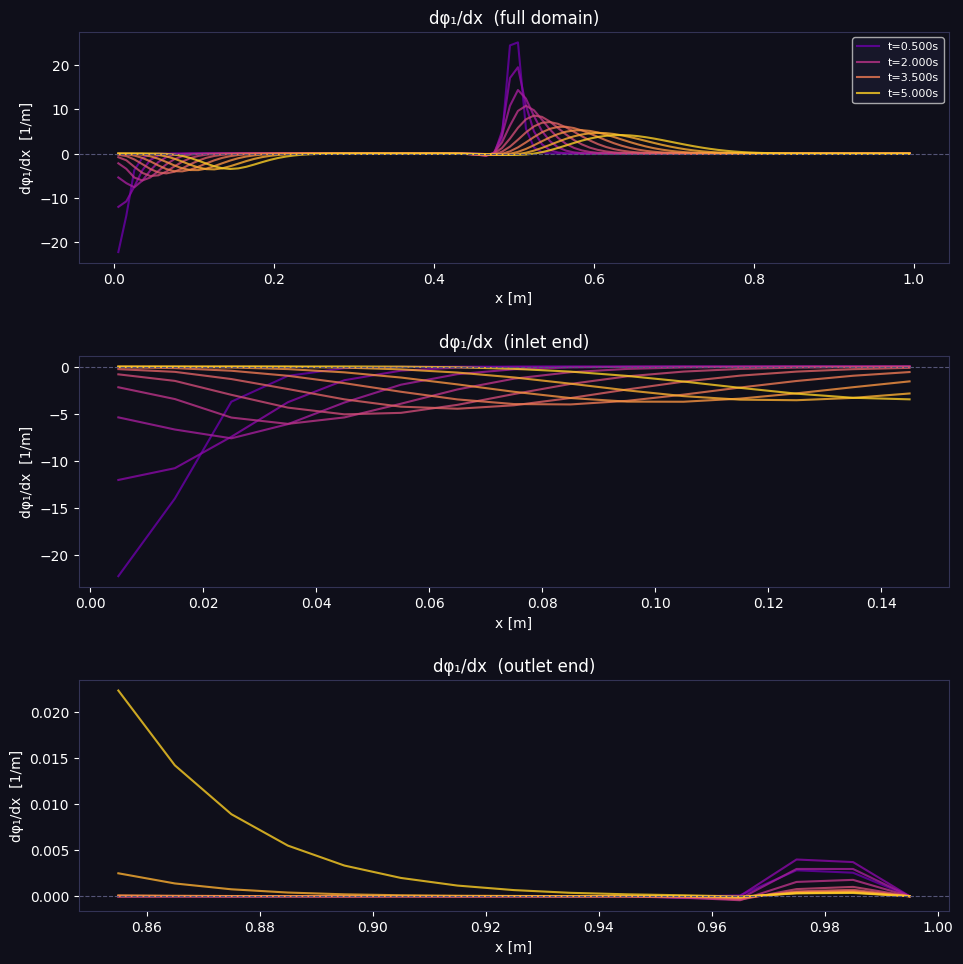

In [168]:
import numpy as np
import matplotlib.pyplot as plt

x_np = np.array(x)

fig, axes = plt.subplots(3, 1, figsize=(10, 10))
fig.patch.set_facecolor('#0f0f1a')
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(saved_times)))

# --- compute and plot dφ₁/dx for every saved snapshot ---
ax_full, ax_left, ax_right = axes

zoom_cells = 15  # how many cells from each end to zoom into

for i, (phi1, color) in enumerate(zip(saved_phi1, colors)):
    dphi_dx = np.gradient(phi1, x_np)           # same length as phi1
    label = f't={saved_times[i]:.3f}s' if i % 3 == 0 else None

    ax_full.plot(x_np, dphi_dx, color=color, linewidth=1.5, alpha=0.8, label=label)
    ax_left.plot(x_np[:zoom_cells], dphi_dx[:zoom_cells], color=color, linewidth=1.5, alpha=0.8)
    ax_right.plot(x_np[-zoom_cells:], dphi_dx[-zoom_cells:], color=color, linewidth=1.5, alpha=0.8)

for ax, title in zip(axes, ['dφ₁/dx  (full domain)', 'dφ₁/dx  (inlet end)', 'dφ₁/dx  (outlet end)']):
    ax.set_facecolor('#0f0f1a')
    ax.set_xlabel('x [m]', color='white')
    ax.set_ylabel('dφ₁/dx  [1/m]', color='white')
    ax.set_title(title, color='white')
    ax.tick_params(colors='white')
    ax.spines[:].set_color('#333355')
    ax.axhline(0, color='#555577', linewidth=0.8, linestyle='--')

ax_full.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8, loc='best')

plt.tight_layout(pad=2.0)
plt.show()


In [172]:
print(np.max(dphi_dx[0:50]))
print(np.max(dphi_dx[50:100]))

0.02018789409854449
4.183208899950717


In [159]:
# --- Oil (EXXSOL D140) parameters ---
L          = 1.0      # pipe length [m]
D          = 0.038    # pipe diameter [m] — matches their 38mm test section
N          = 100      # number of cells
theta      = 0.0     # pipe inclination angle from horizontal [radians], # 0 = horizontal, π/2 = vertical
rho1_val   = 1000.0   # water [kg/m³]
rho2_val   = 828.0   # oil [kg/m³]
phi1_0     = 0.10     # % water
p_inlet    = 1.1e5    # [Pa]
p_outlet   = 1.0000e5    # [Pa]
mu1        = 1e-3     # water [Pa·s]
mu2        = 6e-3     # oil [Pa·s]
#drag_coeff = 50000.0   # [kg/(m³·s)]
drag_coeff = 0.01    # [kg/(m³·s)] — use with the new drag model
d_b       = 1e-3     # effective particle diameter for drag [m]
t_end      = 6.0      # [s]
#dt_max     = 1e-4

u_steady = np.sqrt(2 * D * (p_inlet - p_outlet) / (0.02 * (rho1_val * phi1_0 + rho2_val * (1 - phi1_0)) * L))
slip  = np.sqrt(phi1_0 * (p_inlet - p_outlet) / (L * drag_coeff * 0.75 * rho1_val / d_b))

print(f"Estimated steady-state velocity: {u_steady:.4f} m/s")
print(f"Estimated slip velocity: {slip:.4f} m/s")


Estimated steady-state velocity: 6.7052 m/s
Estimated slip velocity: 0.3651 m/s


# visualizing cylinder 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_solution_on_pipe(x, phi1, u1, L, R=0.1):
    """
    Visualize 1D solution extruded onto a cylindrical surface.
    phi1, u1 are 1D arrays — we wrap them around the cylinder
    purely for visual representation.
    """
    fig = plt.figure(figsize=(14, 5))
    fig.patch.set_facecolor('#0f0f1a')

    # --- Build cylinder surface ---
    theta = np.linspace(0, 2 * np.pi, 40)
    x_np  = np.array(x)

    # Meshgrid: theta around circumference, x along pipe
    THETA, X = np.meshgrid(theta, x_np)
    Y = R * np.cos(THETA)
    Z = R * np.sin(THETA)

    # Extrude phi1 values: same value all around circumference at each x
    # phi1 is (N,) — broadcast to (N, 40) by repeating across theta
    PHI1 = np.array(phi1)[:, None] * np.ones_like(THETA)

    # --- Plot ---
    ax = fig.add_subplot(111, projection='3d')
    ax.set_facecolor('#0f0f1a')

    surf = ax.plot_surface(X, Y, Z,
                           facecolors=plt.cm.viridis(PHI1 / PHI1.max()),
                           alpha=0.85,
                           rstride=1, cstride=2)

    # Colorbar
    m = plt.cm.ScalarMappable(cmap='viridis')
    m.set_array(PHI1)
    plt.colorbar(m, ax=ax, shrink=0.5, label='φ₁ (volume fraction)')

    ax.set_xlabel('x [m]', color='white')
    ax.set_ylabel('y [m]', color='white')
    ax.set_zlabel('z [m]', color='white')
    ax.set_title('Volume Fraction φ₁ along pipe', color='white')
    ax.tick_params(colors='white')
    for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
        pane.fill = False
        pane.set_edgecolor('#333355')

    plt.tight_layout()
    plt.savefig("pipe_solution.png", dpi=150,
                bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()
    
phi1_final, _, u1_final, _, _, u2_final, p_final = (
    state['phi1'], state['rho1'], state['u1'],
    state['phi2'], state['rho2'], state['u2'], state['p']
)

plot_solution_on_pipe(np.array(x), np.array(phi1_final), 
                      np.array(u1_final), L, R=0.1)